In [13]:
import os
print(os.getcwd())

e:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\scripts


In [14]:
import os                           # Manejo de Directorios
import json                         # Manejo de vectores en el .csv
import pandas as pd                 # Manejo de Dataframes
import matplotlib.pyplot as plt     # Gráficos
from PIL import Image, ImageOps     # Gráficos de Imágenes
import numpy as np                  # Números en general

# Librerías para definir el modelo de IA
from keras.models import Model
from keras.layers import Conv1D, Dense, Flatten, Input, Add, Dropout, ReLU, BatchNormalization

# Librearías para definir el entrenamiento de la IA
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, History

from keras.optimizers import Adam
from keras.losses import MeanSquaredError
from keras.metrics import MeanAbsoluteError

# Librerías para Separación de Datos
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold

# Librería de Procesamiento de imágenes
import libs.CameraProcessor as cp

# Tipos de datos
from typing import Tuple
from matplotlib.axes import Axes
from matplotlib.figure import Figure


# Variables

In [15]:
# Path absoluto a direcciones de informacion
path_sensors_csv = "E:\\Agustin\\Escritorio\\Mapeo-por-imagen_GIAR\\scripts\\csv_sensores"
path_img_raw = "E:\\Agustin\\Escritorio\\Mapeo-por-imagen_GIAR\\scripts\\images_raw"

path_ds = "E:\\Agustin\\Escritorio\\Mapeo-por-imagen_GIAR\\scripts\\dataset"


# Variables para calibrar las imágenes. Pueden modificarse a gusto consumidor
color_filter = ((80, 120, 50), (160, 255, 255)) # Corresponde a AZUL
corner_ids = [15,15,15,15]
map_size = (800, 800)       # En mm
pixels_per_mm = 2           # Resolution
path_file_calib_matrix = "E:\\Agustin\\Escritorio\\Mapeo-por-imagen_GIAR\\scripts\\Examples\\calib_matrix_celu_agus.npz"

# Variables de entrenamiento de la IA
callbacks = [EarlyStopping(
            monitor="val_loss",
            patience=10,
            restore_best_weights=False
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=5,
            min_lr=1e-6
        ),
        ModelCheckpoint(
            filepath="mejor_modelo.keras",
            monitor="val_loss",
            save_best_only=True
        )
]


# Funciones

### Funciones del dataframe

Funciones utilizadas para limpiar la información original, crear los .CSV y cargar los .CSV al programa

In [16]:
def csv_merge(csv_dir, img_dir, out_dir, distances, angles, img_names):
    '''
    Añade a los .CSV del microcontrolador la información de su imagen asociada. Lo guarda todo en un CSV en out_dir
    '''
    os.makedirs(out_dir, exist_ok=True)

    normalized_img_names = []
    for name in img_names:
        bn = os.path.basename(name).lower()
        normalized_img_names.append(bn)

    # Dictionary: {file_name}: num
    img_map = { normalized_img_names[i]: i for i in range(len(img_names)) }

    img_ids = set()
    for name in normalized_img_names:
        base, ext = os.path.splitext(name)
        if base.isdigit():
            img_ids.add(int(base))

    csv_files = sorted(
        [f for f in os.listdir(csv_dir) if f.endswith(".csv")],
        key=lambda x: int(x.replace(".csv", ""))
    )

    for csv_file in csv_files:
        csv_id = int(csv_file.replace(".csv", ""))
        in_path = os.path.join(csv_dir, csv_file)
        out_path = os.path.join(out_dir, csv_file)
        df = pd.read_csv(in_path)

        found_match = False
        for ext in [".jpeg", ".jpg", ".png"]:
            expected_img = f"{csv_id}{ext}"
            expected_img = expected_img.lower()

            if expected_img in img_map:
                idx = img_map[expected_img]
                df.loc[0, "angulos_mapa"] = json.dumps(angles[idx])
                df.loc[0, "distancias_mapa"] = json.dumps(distances[idx])
                df.loc[0, "image_path"] = os.path.join(img_dir, expected_img)
                print(f"[OK] {csv_file} + {expected_img} fusionado.")
                found_match = True
                break

        # No hay imagen -> agregar columnas vacías
        if not found_match:
            df.loc[0, "angulos_mapa"] = ""
            df.loc[0, "distancias_mapa"] = ""
            print(f"[WARN] {csv_file} sin imagen -> columnas vacías.")

        df.to_csv(out_path, index=False)

    print("\nFUSIÓN COMPLETADA.")

def load_dataset(dataset_dir)->pd.DataFrame:
    """
    Carga todos los CSV del directorio dataset_dir.
    Retorna un DataFrame consolidado con columnas:
      id, fecha, imagen_path (si existe), angulo (lista),
      ultrasonico (lista), infrarrojo (lista), kalman (lista),
      distancias_mapa (lista, si existe), angulos_mapa (lista, si existe)
    """
    records = []
    for fname in os.listdir(dataset_dir):
        if not fname.lower().endswith(".csv"):
            continue
        path = os.path.join(dataset_dir, fname)
        df = pd.read_csv(path)

        row = df.iloc[0].to_dict()
        for col in ["angulo", "ultrasonico", "infrarrojo", "kalman", 
                    "distancias_mapa", "angulos_mapa"]:
            if col in row and pd.notna(row[col]) and row[col] != "":
                try:
                    row[col] = json.loads(row[col])
                except json.JSONDecodeError:
                    row[col] = None
            else:
                row[col] = None

        records.append(row)
    df = pd.DataFrame(records)
    
    df.set_index('id', inplace=True)

    return df

def plot_polar(angles_deg, values, title=None, ax:plt.Axes=None, 
               threshold=None, threshold_color="red", **plot_kwargs):
    if ax is None:
        fig = plt.figure(figsize=(6,6))
        ax = fig.add_subplot(111, projection="polar")
    else:
        fig = ax.figure

    angles_rad = np.deg2rad(angles_deg)
    ax.plot(angles_rad, values, **plot_kwargs)

    # Limite
    if threshold is not None:
        full_circle = np.linspace(0, 2*np.pi, 400)
        r_max = max(max(values), threshold * 1.2)
        ax.fill_between(full_circle, threshold, r_max, color=threshold_color, alpha=0.2)
        ax.plot(full_circle, np.full_like(full_circle, threshold), color=threshold_color, linestyle="--", linewidth=1.5)

    ax.set_theta_zero_location("E")
    ax.set_theta_direction(1)

    if title:
        ax.set_title(title)

    ax.grid(True)
    return fig, ax

def plot_all_scans(df: pd.DataFrame, idx, mode="side"):
    """
    mode="side": 3 subplots polares, lado a lado
    mode="overlay": 3 curvas superpuestas en 1 solo polar
    """

    row = df.iloc[idx]
    ang = row["angulo"]
    us  = row["ultrasonico"]
    ir  = row["infrarrojo"]
    ang_map = row.get("angulos_mapa")
    dist_map = row.get("distancias_mapa")
    
    scan_id = row.get("id", idx)

    # --- MODO SUBPLOTS LATERALES ---
    if mode == "side":
        fig = plt.figure(figsize=(18,6))
        
        # Ultrasonido
        ax1 = fig.add_subplot(131, projection="polar")
        plot_polar(ang, us, title="Ultrasonido", ax=ax1)

        # Infrarrojo
        ax2 = fig.add_subplot(132, projection="polar")
        plot_polar(ang, ir, title="Infrarrojo", ax=ax2)

        # Imagen procesada
        ax3 = fig.add_subplot(133, projection="polar")
        plot_polar(ang_map, dist_map, title="Foto procesada", ax=ax3)

        fig.suptitle(f"Medición ID {scan_id}", fontsize=14)
        plt.tight_layout()
        plt.show()
        return fig

    # --- MODO SUPERPUESTO ---
    elif mode == "overlay":
        fig = plt.figure(figsize=(7,7))
        ax = fig.add_subplot(111, projection="polar")

        plot_polar(ang, us,  ax=ax, label="Ultrasonido")
        plot_polar(ang, ir,  ax=ax, label="Infrarrojo")
        plot_polar(ang_map, dist_map, ax=ax, label="Distancia mapa")

        ax.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1))
        ax.set_title(f"Medición ID {scan_id} — Comparación")

        plt.show()
        return fig

    else:
        raise ValueError('mode debe ser "side" o "overlay"')


### Funciones del Modelo

Funciones para definir el modelo de IA a realizar y entrenar. También posee funciones para obtener de un dataframe las variables de entrada del modelo

In [17]:
def resnet_block(x, filters, kernel_size):
    shortcut = x

    # Conv 1
    x = Conv1D(filters, kernel_size, padding="same", use_bias=False)(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    # Conv 2
    x = Conv1D(filters, kernel_size, padding="same", use_bias=False)(x)
    x = BatchNormalization()(x)

    # Proyección del shortcut si cambian los canales
    if shortcut.shape[-1] != filters:
        shortcut = Conv1D(filters, 1, padding="same", use_bias=False)(shortcut)
        shortcut = BatchNormalization()(shortcut)

    # Suma residual + activación final
    x = Add()([x, shortcut])
    x = ReLU()(x)

    return x

def internal_block(x, filters, kernel_size):
    shortcut = x
    x = Conv1D(filters, kernel_size, padding="same", activation=None)(x)
    x = Conv1D(filters, kernel_size, padding="same", activation=None)(x)

    # Ajuste del shortcut si cambia el número de filtros
    if shortcut.shape[-1] != filters:
        shortcut = Conv1D( filters, 1, padding="same", activation=None)(shortcut)
    x = Add()([x, shortcut])

    return x

def init_model(seq_len=61):
    inp = Input(shape=(seq_len, 2))

    #x = internal_block(inp, filters=32, kernel_size=5)   # Bloque 1
    #x = internal_block(x, filters=64, kernel_size=3)     # Bloque 2
    #x = internal_block(x, filters=64, kernel_size=3)     # Bloque 3
    x = resnet_block(inp, filters=32, kernel_size=5)   # Bloque 1
    x = resnet_block(x, filters=64, kernel_size=3)     # Bloque 2
    x = resnet_block(x, filters=64, kernel_size=3)     # Bloque 3

    x = Flatten()(x)
    x = Dense(128, activation="relu")(x)
    #x = Dropout(0.3)(x)
    out = Dense(seq_len, activation="linear")(x)

    model = Model(inp, out)
    model.compile(
        optimizer=Adam(1e-3),
        loss=MeanSquaredError(),
        metrics=[MeanAbsoluteError()]
    )

    return model

def get_data(df: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:
    X = []
    Y = []

    for _, row in df.iterrows():
        us = row['ultrasonico']        
        ir = row['infrarrojo']         
        real = row['distancias_mapa']  

        # Entrada (61,2)
        entrada = np.column_stack([us, ir])  
        X.append(entrada)
        Y.append(real)

    return np.array(X), np.array(Y)

def crossvalidate_model(X, Y, k=5, epochs=80, batch_size=16):       # No se utilizó. Folds muy pequeños, daba resultados muy malos
    kf = KFold(n_splits=k, shuffle=True)
    results = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        print(f"\n=== Fold {fold+1}/{k} ===")
        X_train, X_val = X[train_idx], X[val_idx]
        Y_train, Y_val = Y[train_idx], Y[val_idx]

        model = init_model(seq_len=X.shape[1])

        model.fit(
            X_train, Y_train,
            validation_data=(X_val, Y_val),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=callbacks,
            verbose=0
        )

        loss_val, mae_val = model.evaluate(X_val, Y_val, verbose=0)
        print(f"Fold {fold+1} -> Loss: {loss_val:.4f}, MAE: {mae_val:.4f}")

        results.append((loss_val, mae_val))

    return np.array(results)




### Funciones de métricas

Creadas para poder comparar y visualizar resultados

In [18]:
def plot_history(history: History)->Tuple[Figure, Tuple[Axes, Axes]]:
    """
    Grafica el historial de entrenamiento de Keras en dos subplots:
    - Loss (train y val)
    - MAE (train y val, si existe)
    """

    fig, axes = plt.subplots(2, 1, figsize=(10, 10))
    ax_loss, ax_mae = axes

    # LOSS
    ax_loss.plot(history.history["loss"], label="Loss (train)")
    ax_loss.plot(history.history["val_loss"], label="Loss (val)")

    ax_loss.set_xlabel("Epoch")
    ax_loss.set_ylabel("Loss")
    ax_loss.set_title("Evolución del Loss")
    ax_loss.legend()
    ax_loss.grid(True)

    if "mean_absolute_error" in history.history:
        ax_mae.plot(history.history["mean_absolute_error"], label="MAE (train)")
        ax_mae.plot(history.history["val_mean_absolute_error"], label="MAE (val)")
        ax_mae.set_title("Evolución del MAE")
    else:
        ax_mae.text(0.5, 0.5, "MAE no disponible", ha='center', va='center')

    ax_mae.set_xlabel("Epoch")
    ax_mae.set_ylabel("MAE")
    ax_mae.legend()
    ax_mae.grid(True)

    plt.tight_layout()
    return fig, axes

def mae(y_true, y_pred):
    """Mean Absolute Error global para arrays (N, L)."""
    return np.mean(np.abs(y_true - y_pred))

def mse(y_true, y_pred):
    """Mean Squared Error global."""
    return np.mean((y_true - y_pred)**2)

def rmse(y_true, y_pred):
    """Root Mean Squared Error global."""
    return np.sqrt(mse(y_true, y_pred))

def mape(y_true, y_pred):
    """Mean Absolute Percentage Error (ignora ceros en y_true)."""
    y_true = y_true.astype(float)
    mask = np.abs(y_true) > 1e-8
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def metrics(y_true, y_pred):
    """Retorna todas las métricas en un diccionario."""
    return {
        "MAE": mae(y_true, y_pred),
        "MSE": mse(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MAPE(%)": mape(y_true, y_pred),
    }


# Carga del Dataset

## Creacion del Dataset

Se transforma la información original en un dataset unificado.
La información original es:
* Una carpeta con .csv con las mediciones del microcontrolador.
* Una carpeta con la foto correspondiente de cada medición del microcontrolador.

Procesando (distancias): E:\Agustin\Escritorio\Mapeo-por-imagen_GIAR\scripts\images_raw\WhatsApp Image 2026-03-04 at 17.30.24.jpeg



(<Figure size 600x600 with 1 Axes>, <PolarAxes: >)

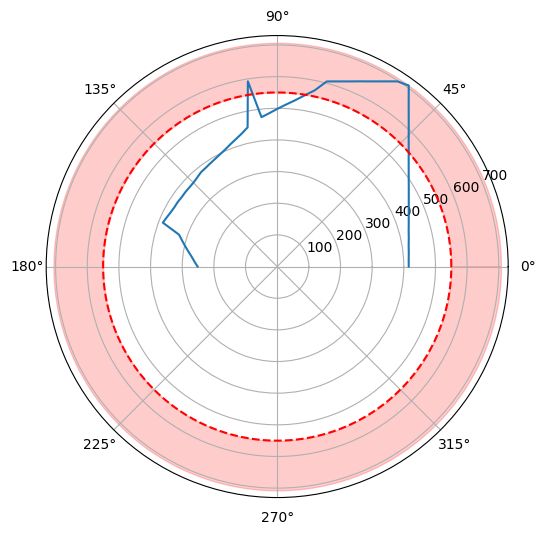

In [20]:
# Cargo y calibro la cámara
cam = cp.CameraProcessor()
cam.loadCalibMatrix(path_file_calib_matrix)

# Corrijo las fotos
distances, angles, img_names = cam.processDistances(path_img_raw, corner_ids, color_filter, map_size, pixels_per_mm, angle_step=3)
plot_polar(angles[0], distances[0], threshold=550)

# Uno los resultados a los csv del microcontrolador
# csv_merge(path_sensors_csv, path_img_raw , path_ds, distances=distances, angles=angles, img_names=img_names)

## Carga del Dataset en Python

Se carga la carpeta con los .csv y se limpia el dataframe para poder ser utilizado luego.

In [ ]:
# Cargo el dataframe
df = load_dataset(path_ds)

# Limpio el dataframe
df = df[
    (df["ultrasonico"].str.len() == 61) &
    (df["infrarrojo"].str.len() == 61) &
    (df["distancias_mapa"].str.len() == 61)
]
df.drop('imagen_path', axis=1, inplace=True)
df.info()

In [ ]:
df

In [ ]:
idx = 83
plot_all_scans(df, idx, mode='overlay');

# Entrenamiento de IA

In [ ]:
X, Y = get_data(df)
indices = df.index.to_numpy()

X_trainval, X_test, Y_trainval, Y_test, idx_trainval, idx_test = train_test_split(
    X, Y, indices,
    test_size=0.1,
    shuffle=True,
    random_state=21
)


## CrossValidacion de Resultados

In [ ]:
# cv_results = crossvalidate_model(X_trainval, Y_trainval, k=5)

# print("\n=== Resultados Cross-Validation ===")
# print("Loss promedio:", cv_results[:,0].mean())
# print("Loss std:     ", cv_results[:,0].std())
# print("MAE promedio:", cv_results[:,1].mean())
# print("MAE std:     ", cv_results[:,1].std())


## Entrenamiento final

In [ ]:
model_final = init_model(seq_len=X.shape[1])
model_final.summary()

In [ ]:
history = model_final.fit(
    X_trainval,
    Y_trainval,
    validation_split=0.15,
    epochs=80,
    batch_size=16,
    callbacks=callbacks
)


# Verificacion de resultados


In [ ]:
fig, ax = plot_history(history)
ax[0].set_ylim(0, 10e3)
#ax[1].set_ylim(0, 10e3)
plt.show()


In [ ]:
loss_test, mae_test = model_final.evaluate(X_test, Y_test, verbose=0)

print("\n=== RESULTADOS FINALES ===")
print(f'TRAIN Loss: {min(history.history['loss']):.4f}')
print(f'TRAIN MAE: {min(history.history['mean_absolute_error']):.4f}\n')
print(f'VAL Loss: {min(history.history['val_loss']):.4f}')
print(f'VAL MAE: {min(history.history['val_mean_absolute_error']):.4f}\n')
print(f"TEST Loss: {loss_test:.4f}")
print(f"TEST MAE:  {mae_test:.4f}\n")



In [ ]:
X, Y = get_data(df) 
kalman = np.stack(df['kalman'].to_list())
img_path = df['image_path'].to_numpy()
pred = model_final.predict(X)

_aux = metrics(Y, kalman)
print("Métricas Globales Kalman:")
print(f'MAE:\t\t{_aux['MAE']:.4f}\nMSE:\t\t{_aux['MSE']:.4f}\nRMSE:\t\t{_aux['RMSE']:.4f}\nMAPE(%):\t{_aux['MAPE(%)']:.4f}')

_aux = metrics(Y, pred) 
print("\nMétricas Globales IA:")
print(f'MAE:\t\t{_aux['MAE']:.4f}\nMSE:\t\t{_aux['MSE']:.4f}\nRMSE:\t\t{_aux['RMSE']:.4f}\nMAPE(%):\t{_aux['MAPE(%)']:.4f}')


In [ ]:
idx = np.random.randint(len(X))
us = X[idx][:, 0]
ir = X[idx][:, 1]

print(img_path[idx])

fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection="polar")

angulos = np.linspace(0, 180, len(Y[idx]))
plot_polar(angulos, Y[idx], threshold=400, ax=ax, label="Real")
plot_polar(angulos, pred[idx], ax=ax, label="Predicho")
plot_polar(angulos, us, ax=ax, label="Ultrasonico")
plot_polar(angulos, ir, ax=ax, label="Infrarrojo")

[ymin, _] = ax.get_ylim()
ax.set_ylim(ymin, 410)

ax.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1))
ax.set_title(f"Comparación Sensores (idx={idx})")
plt.show()


In [ ]:
fig = plt.figure(figsize=(12,10))

# Prediccion
ax_polar = fig.add_subplot(1, 2, 1, projection="polar")
plot_polar(angulos, Y[idx], threshold=400, ax=ax_polar, label="Real")
plot_polar(angulos, pred[idx], ax=ax_polar, label="Predicho")
plot_polar(angulos, kalman[idx], ax=ax_polar, label="Kalman")

[ymin, _] = ax_polar.get_ylim()
ax_polar.set_ylim(ymin, 410)
ax_polar.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1))
ax_polar.set_title(f"Comparación con Kalman (idx={idx})")

# Imagen
ax_img = fig.add_subplot(1, 2, 2)
img = Image.open(img_path[idx])
img = ImageOps.exif_transpose(img)   # Corrige la rotación automáticamente
img = np.array(img)

ax_img.imshow(img)
ax_img.axis("off")


plt.tight_layout()
plt.show()


In [ ]:
idx = np.random.randint(len(X_test))   
orig_idx = idx_test[idx]               

y_real = Y_test[idx]
y_pred = model_final.predict(X_test[idx:idx+1])[0]
y_kalman = df.loc[orig_idx, "kalman"]
img_path_test = df.loc[orig_idx, "image_path"]


angulos = np.linspace(0, 180, len(Y[idx]))

us = X_test[idx][:, 0]
ir = X_test[idx][:, 1]


## Prueba random de test
fig = plt.figure(figsize=(12,10))

# Prediccion
ax_polar = fig.add_subplot(1, 2, 1, projection="polar")
plot_polar(angulos, y_real, threshold=400, ax=ax_polar, label="Real")
plot_polar(angulos, y_pred, ax=ax_polar, label="Predicho")
plot_polar(angulos, y_kalman, ax=ax_polar, label="Kalman")

[ymin, _] = ax_polar.get_ylim()
ax_polar.set_ylim(ymin, 410)
ax_polar.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1))
ax_polar.set_title(f"Comparación con Kalman (idx={idx})")

# Imagen
ax_img = fig.add_subplot(1, 2, 2)
img = Image.open(img_path_test)
img = ImageOps.exif_transpose(img)   # Corrige la rotación automáticamente
img = np.array(img)

ax_img.imshow(img)
ax_img.axis("off")


plt.tight_layout()
plt.show()
